# NBFC Loan Portfolio Risk & Analytics

## Project Objective

Analyze an NBFC loan portfolio to identify portfolio concentration, customer credit risk, affordability risk, delinquency patterns, and default exposure.

**Tools:** Python, Pandas, NumPy, Matplotlib, SQL, Power BI

**Dataset:** 8,000 synthetic loan records

This notebook covers data validation, feature engineering, portfolio KPIs, risk segmentation, and business-oriented risk analysis. The final outputs are designed to support the Power BI dashboard and SQL analysis.


## 1. Import Libraries & Load Dataset

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the final V2 loan portfolio dataset
df = pd.read_csv("loan_portfolio.csv")

print("Dataset loaded successfully!")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()


Dataset loaded successfully!
Rows: 8,000
Columns: 14


,customer_id,age,city,employment_type,monthly_income,credit_score,product,loan_amount,tenure_months,interest_rate,emi,disbursement_date,days_past_due,default_flag
0,CUST100000,42,Kolkata,Self-Employed,45746,705,Personal Loan,575583,48,16.38,16424.42,2024-03-04,0,0
1,CUST100001,48,Jaipur,Salaried,39575,613,Business Loan,423123,60,12.63,9547.40,2024-04-21,1,0
2,CUST100002,35,Jaipur,Business Owner,48294,625,Gold Loan,315842,24,9.96,14568.68,2024-06-12,0,0
3,CUST100003,35,Hyderabad,Salaried,25000,586,Business Loan,232445,60,15.19,5553.06,2023-09-30,179,1
4,CUST100004,45,Lucknow,Business Owner,37456,594,Business Loan,166122,12,11.52,14722.46,2024-05-09,314,1


## 2. Data Structure & Data Quality

First, confirm the dataset structure, data types, missing values, and duplicate records before performing analysis.


In [38]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        8000 non-null   object 
 1   age                8000 non-null   int64  
 2   city               8000 non-null   object 
 3   employment_type    8000 non-null   object 
 4   monthly_income     8000 non-null   int64  
 5   credit_score       8000 non-null   int64  
 6   product            8000 non-null   object 
 7   loan_amount        8000 non-null   int64  
 8   tenure_months      8000 non-null   int64  
 9   interest_rate      8000 non-null   float64
 10  emi                8000 non-null   float64
 11  disbursement_date  8000 non-null   object 
 12  days_past_due      8000 non-null   int64  
 13  default_flag       8000 non-null   int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 875.1+ KB


In [39]:
print("=== MISSING VALUE CHECK ===")
missing = df.isnull().sum()
print(missing)
print("\nTotal missing values:", missing.sum())

print("\n=== DUPLICATE CHECK ===")
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["customer_id"].duplicated().sum())


=== MISSING VALUE CHECK ===
customer_id          0
age                  0
city                 0
employment_type      0
monthly_income       0
credit_score         0
product              0
loan_amount          0
tenure_months        0
interest_rate        0
emi                  0
disbursement_date    0
days_past_due        0
default_flag         0
dtype: int64

Total missing values: 0

=== DUPLICATE CHECK ===
Duplicate rows: 0
Duplicate Customer IDs: 0


## 3. Business Rule Validation

The portfolio is checked for sensible numerical ranges and for consistency between `default_flag` and 90+ DPD status.


In [40]:
print("=== NUMERICAL RANGE CHECK ===\n")

checks = {
    "Age": (df["age"].min(), df["age"].max()),
    "Monthly Income": (df["monthly_income"].min(), df["monthly_income"].max()),
    "Credit Score": (df["credit_score"].min(), df["credit_score"].max()),
    "Loan Amount": (df["loan_amount"].min(), df["loan_amount"].max()),
    "Tenure (months)": (df["tenure_months"].min(), df["tenure_months"].max()),
    "Interest Rate (%)": (df["interest_rate"].min(), df["interest_rate"].max()),
    "EMI": (df["emi"].min(), df["emi"].max()),
    "Days Past Due": (df["days_past_due"].min(), df["days_past_due"].max()),
    "Default Flag": (df["default_flag"].min(), df["default_flag"].max())
}

for variable, (minimum, maximum) in checks.items():
    print(f"{variable:<25} Min: {minimum:<12} Max: {maximum}")


=== NUMERICAL RANGE CHECK ===

Age                       Min: 21           Max: 65
Monthly Income            Min: 15000        Max: 345034
Credit Score              Min: 347          Max: 900
Loan Amount               Min: 25000        Max: 6120720
Tenure (months)           Min: 6            Max: 300
Interest Rate (%)         Min: 8.5          Max: 18.99
EMI                       Min: 1337.83      Max: 78207.84
Days Past Due             Min: 0            Max: 364
Default Flag              Min: 0            Max: 1


In [41]:
default_without_dpd = (
    (df["default_flag"] == 1) &
    (df["days_past_due"] < 90)
).sum()

dpd_without_default = (
    (df["days_past_due"] >= 90) &
    (df["default_flag"] == 0)
).sum()

print("=== DEFAULT / DPD CONSISTENCY ===")
print("Defaults with DPD < 90:", default_without_dpd)
print("Non-defaults with DPD >= 90:", dpd_without_default)


=== DEFAULT / DPD CONSISTENCY ===
Defaults with DPD < 90: 0
Non-defaults with DPD >= 90: 0


## 4. Derived Affordability & Exposure Metrics

Two core risk indicators are calculated:

- **EMI-to-Income:** monthly EMI as a percentage of monthly income.
- **Loan-to-Annual-Income (LTI):** loan amount divided by annual income.


In [42]:
df["emi_to_income"] = (
    df["emi"] / df["monthly_income"]
) * 100

df["loan_to_annual_income"] = (
    df["loan_amount"] /
    (df["monthly_income"] * 12)
)

print("=== EMI-TO-INCOME ===")
print(f"Minimum: {df['emi_to_income'].min():.2f}%")
print(f"Average: {df['emi_to_income'].mean():.2f}%")
print(f"Maximum: {df['emi_to_income'].max():.2f}%")
print("Loans with EMI-to-Income > 50%:", (df["emi_to_income"] > 50).sum())

print("\n=== LOAN-TO-ANNUAL-INCOME ===")
print(f"Average: {df['loan_to_annual_income'].mean():.2f}x")
print(f"Median: {df['loan_to_annual_income'].median():.2f}x")
print(f"90th percentile: {df['loan_to_annual_income'].quantile(.90):.2f}x")
print(f"Maximum: {df['loan_to_annual_income'].max():.2f}x")


=== EMI-TO-INCOME ===
Minimum: 0.83%
Average: 23.26%
Maximum: 45.00%
Loans with EMI-to-Income > 50%: 0

=== LOAN-TO-ANNUAL-INCOME ===
Average: 0.80x
Median: 0.44x
90th percentile: 2.27x
Maximum: 4.03x


## 5. Final Data Quality Audit

In [43]:
print("============================================")
print("        FINAL DATA QUALITY AUDIT")
print("============================================\n")

print("Rows:", len(df))
print("Columns after derived metrics:", len(df.columns))
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["customer_id"].duplicated().sum())

default_low_dpd = (
    (df["default_flag"] == 1) &
    (df["days_past_due"] < 90)
).sum()

nondefault_high_dpd = (
    (df["default_flag"] == 0) &
    (df["days_past_due"] >= 90)
).sum()

print("Defaults with DPD < 90:", default_low_dpd)
print("Non-defaults with DPD >= 90:", nondefault_high_dpd)

print("\nDefault distribution:")
print(df["default_flag"].value_counts().sort_index())

print(f"\nDefault rate: {df['default_flag'].mean() * 100:.2f}%")


        FINAL DATA QUALITY AUDIT

Rows: 8000
Columns after derived metrics: 16
Total missing values: 0
Duplicate rows: 0
Duplicate Customer IDs: 0
Defaults with DPD < 90: 0
Non-defaults with DPD >= 90: 0

Default distribution:
default_flag
0    7002
1     998
Name: count, dtype: int64

Default rate: 12.47%


## 6. Feature Engineering

Create categorical risk bands used for segmentation and dashboard analysis.


In [44]:
df["credit_risk_band"] = pd.cut(
    df["credit_score"],
    bins=[0, 579, 669, 739, 799, 900],
    labels=["Poor", "Fair", "Good", "Very Good", "Excellent"],
    include_lowest=True
)

df["emi_burden_band"] = pd.cut(
    df["emi_to_income"],
    bins=[0, 20, 30, 40, 50],
    labels=["Low Burden", "Moderate", "High", "Very High"],
    include_lowest=True
)

df["dpd_category"] = pd.cut(
    df["days_past_due"],
    bins=[-1, 0, 30, 60, 89, float("inf")],
    labels=["Current", "1-30 DPD", "31-60 DPD", "61-89 DPD", "90+ DPD"]
)

df["income_band"] = pd.cut(
    df["monthly_income"],
    bins=[0, 25000, 50000, 100000, 200000, float("inf")],
    labels=["<25K", "25K-50K", "50K-1L", "1L-2L", "2L+"],
    include_lowest=True
)

df["loan_size_band"] = pd.cut(
    df["loan_amount"],
    bins=[0, 100000, 500000, 1000000, 2500000, 5000000, float("inf")],
    labels=["<1L", "1L-5L", "5L-10L", "10L-25L", "25L-50L", "50L+"],
    include_lowest=True
)

df["age_group"] = pd.cut(
    df["age"],
    bins=[20, 30, 40, 50, 60, 70],
    labels=["21-30", "31-40", "41-50", "51-60", "61-65"],
    include_lowest=True
)

df["loan_to_income_band"] = pd.cut(
    df["loan_to_annual_income"],
    bins=[0, 0.5, 1, 2, 3, float("inf")],
    labels=["<0.5x", "0.5-1x", "1-2x", "2-3x", "3x+"],
    include_lowest=True
)

engineered_features = [
    "credit_risk_band", "emi_burden_band", "dpd_category",
    "income_band", "loan_size_band", "age_group", "loan_to_income_band"
]

print("Feature engineering completed.")
print("Final dataset shape:", df.shape)


Feature engineering completed.
Final dataset shape: (8000, 23)


In [45]:
print("=== ENGINEERED FEATURE VALIDATION ===")
print(df[engineered_features].isnull().sum())


=== ENGINEERED FEATURE VALIDATION ===
credit_risk_band       0
emi_burden_band        0
dpd_category           0
income_band            0
loan_size_band         0
age_group              0
loan_to_income_band    0
dtype: int64


## 7. Portfolio KPIs

In [46]:
total_customers = df["customer_id"].nunique()
total_exposure = df["loan_amount"].sum()
average_loan = df["loan_amount"].mean()
average_income = df["monthly_income"].mean()
average_emi = df["emi"].mean()
average_interest = df["interest_rate"].mean()
default_customers = df["default_flag"].sum()
default_rate = df["default_flag"].mean() * 100
dpd_90_plus = (df["days_past_due"] >= 90).sum()
dpd_90_plus_exposure = df.loc[
    df["days_past_due"] >= 90, "loan_amount"
].sum()

print("========== PORTFOLIO KPIs ==========")
print(f"Total Customers        : {total_customers:,}")
print(f"Total Loan Exposure    : ₹{total_exposure:,.0f}")
print(f"Average Loan Amount    : ₹{average_loan:,.0f}")
print(f"Average Monthly Income : ₹{average_income:,.0f}")
print(f"Average EMI            : ₹{average_emi:,.0f}")
print(f"Average Interest Rate  : {average_interest:.2f}%")
print(f"Default Customers      : {default_customers:,}")
print(f"Default Rate           : {default_rate:.2f}%")
print(f"90+ DPD Customers      : {dpd_90_plus:,}")
print(f"90+ DPD Exposure       : ₹{dpd_90_plus_exposure:,.0f}")


========== PORTFOLIO KPIs ==========
Total Customers        : 8,000
Total Loan Exposure    : ₹4,170,433,949
Average Loan Amount    : ₹521,304
Average Monthly Income : ₹56,390
Average EMI            : ₹12,541
Average Interest Rate  : 13.08%
Default Customers      : 998
Default Rate           : 12.47%
90+ DPD Customers      : 998
90+ DPD Exposure       : ₹500,331,573


## 8. Product-wise Risk Analysis

In [47]:
product_analysis = df.groupby("product").agg(
    customers=("customer_id", "count"),
    total_exposure=("loan_amount", "sum"),
    average_loan=("loan_amount", "mean"),
    defaults=("default_flag", "sum")
)

product_analysis["default_rate"] = (
    product_analysis["defaults"] /
    product_analysis["customers"]
) * 100

product_analysis["default_exposure"] = (
    df[df["default_flag"] == 1]
    .groupby("product")["loan_amount"]
    .sum()
    .reindex(product_analysis.index, fill_value=0)
)

product_analysis["portfolio_share"] = (
    product_analysis["total_exposure"] /
    product_analysis["total_exposure"].sum()
) * 100

product_analysis["default_exposure_ratio"] = (
    product_analysis["default_exposure"] /
    product_analysis["total_exposure"]
) * 100

product_analysis = product_analysis.sort_values(
    "default_rate", ascending=False
)

product_analysis.round(2)


,customers,total_exposure,average_loan,defaults,default_rate,default_exposure,portfolio_share,default_exposure_ratio
product,,,,,,,,
Business Loan,1591,575920338,361986.38,246,15.46,89710948,13.81,15.58
Personal Loan,2851,648574222,227490.08,354,12.42,90871219,15.55,14.01
Vehicle Loan,761,273743195,359715.11,91,11.96,31603481,6.56,11.54
Gold Loan,1181,176716792,149633.19,130,11.01,18798305,4.24,10.64
Home Loan,1616,2495479402,1544232.30,177,10.95,269347620,59.84,10.79


## 9. Credit Risk Band Analysis

In [48]:
credit_analysis = df.groupby("credit_risk_band", observed=False).agg(
    customers=("customer_id", "count"),
    defaults=("default_flag", "sum"),
    exposure=("loan_amount", "sum")
)

credit_analysis["default_rate"] = (
    credit_analysis["defaults"] / credit_analysis["customers"]
) * 100

credit_analysis["default_exposure"] = (
    df[df["default_flag"] == 1]
    .groupby("credit_risk_band", observed=False)["loan_amount"]
    .sum()
    .reindex(credit_analysis.index, fill_value=0)
)

credit_analysis.round(2)


,customers,defaults,exposure,default_rate,default_exposure
credit_risk_band,,,,,
Poor,1078,203,520783780,18.83,91816322
Fair,2628,330,1398801097,12.56,181948105
Good,2309,243,1213005269,10.52,120799701
Very Good,1241,132,632453305,10.64,66682168
Excellent,744,90,405390498,12.10,39085277


## 10. EMI Burden Analysis

In [49]:
emi_analysis = df.groupby("emi_burden_band", observed=False).agg(
    customers=("customer_id", "count"),
    defaults=("default_flag", "sum"),
    exposure=("loan_amount", "sum")
)

emi_analysis["default_rate"] = (
    emi_analysis["defaults"] / emi_analysis["customers"]
) * 100

emi_analysis["default_exposure"] = (
    df[df["default_flag"] == 1]
    .groupby("emi_burden_band", observed=False)["loan_amount"]
    .sum()
    .reindex(emi_analysis.index, fill_value=0)
)

emi_analysis.round(2)


,customers,defaults,exposure,default_rate,default_exposure
emi_burden_band,,,,,
Low Burden,2885,327,685079948,11.33,77996467
Moderate,3148,372,1839459982,11.82,215556042
High,1621,225,1343955868,13.88,149583201
Very High,346,74,301938151,21.39,57195863


## 11. Loan-to-Income Analysis

In [50]:
lti_analysis = df.groupby("loan_to_income_band", observed=False).agg(
    customers=("customer_id", "count"),
    defaults=("default_flag", "sum"),
    exposure=("loan_amount", "sum")
)

lti_analysis["default_rate"] = (
    lti_analysis["defaults"] / lti_analysis["customers"]
) * 100

lti_analysis.round(2)


,customers,defaults,exposure,default_rate
loan_to_income_band,,,,
<0.5x,4397,543,798974741,12.35
0.5-1x,1785,238,756856296,13.33
1-2x,765,94,875960831,12.29
2-3x,781,91,1242571505,11.65
3x+,272,32,496070576,11.76


## 12. Employment-wise Risk Analysis

In [51]:
employment_analysis = df.groupby("employment_type").agg(
    customers=("customer_id", "count"),
    defaults=("default_flag", "sum"),
    exposure=("loan_amount", "sum")
)

employment_analysis["default_rate"] = (
    employment_analysis["defaults"] /
    employment_analysis["customers"]
) * 100

employment_analysis["default_exposure"] = (
    df[df["default_flag"] == 1]
    .groupby("employment_type")["loan_amount"]
    .sum()
    .reindex(employment_analysis.index, fill_value=0)
)

employment_analysis.round(2)


,customers,defaults,exposure,default_rate,default_exposure
employment_type,,,,,
Business Owner,1187,187,628588486,15.75,91668617
Salaried,4371,478,2269294237,10.94,243840908
Self-Employed,2442,333,1272551226,13.64,164822048


## 13. City-wise Risk Analysis

In [52]:
city_analysis = df.groupby("city").agg(
    customers=("customer_id", "count"),
    defaults=("default_flag", "sum"),
    exposure=("loan_amount", "sum")
)

city_analysis["default_rate"] = (
    city_analysis["defaults"] /
    city_analysis["customers"]
) * 100

city_analysis["default_exposure"] = (
    df[df["default_flag"] == 1]
    .groupby("city")["loan_amount"]
    .sum()
    .reindex(city_analysis.index, fill_value=0)
)

city_analysis = city_analysis.sort_values(
    "default_rate", ascending=False
)

city_analysis.round(2)


,customers,defaults,exposure,default_rate,default_exposure
city,,,,,
Kolkata,791,109,400550481,13.78,49250888
Hyderabad,822,111,407784894,13.50,52832506
Mumbai,787,102,405902243,12.96,55569977
Lucknow,820,106,460791744,12.93,54130597
Delhi,851,106,432132648,12.46,54133036
Chennai,735,90,372663007,12.24,42215807
Jaipur,786,95,415746351,12.09,46433881
Pune,820,99,413599848,12.07,54772803
Bengaluru,768,88,409531178,11.46,41211667


## 14. DPD Analysis

In [53]:
dpd_analysis = df.groupby("dpd_category", observed=False).agg(
    customers=("customer_id", "count"),
    exposure=("loan_amount", "sum")
)

dpd_analysis["portfolio_share"] = (
    dpd_analysis["exposure"] /
    dpd_analysis["exposure"].sum()
) * 100

dpd_analysis.round(2)


,customers,exposure,portfolio_share
dpd_category,,,
Current,5969,3116114924,74.72
1-30 DPD,1033,553987452,13.28
31-60 DPD,0,0,0.00
61-89 DPD,0,0,0.00
90+ DPD,998,500331573,12.00


## 15. Customer Risk Scoring

A rule-based risk score combines three dimensions:

- **Credit risk:** 0–40 points
- **EMI burden:** 0–35 points
- **Loan-to-income:** 0–25 points

Total score = **0–100**.

Risk categories:
- Low Risk: 0–33
- Medium Risk: 34–66
- High Risk: 67–100


In [54]:
# Customer Risk Scoring

# Assign risk points to each dimension
credit_points = {
    "Poor": 40,
    "Fair": 30,
    "Good": 20,
    "Very Good": 10,
    "Excellent": 0
}

emi_points = {
    "Low Burden": 0,
    "Moderate": 10,
    "High": 25,
    "Very High": 35
}

lti_points = {
    "<0.5x": 0,
    "0.5-1x": 5,
    "1-2x": 10,
    "2-3x": 20,
    "3x+": 25
}

# Convert mapped scores explicitly to numeric
df["credit_risk_score"] = (
    df["credit_risk_band"].map(credit_points).astype(int)
)

df["emi_risk_score"] = (
    df["emi_burden_band"].map(emi_points).astype(int)
)

df["lti_risk_score"] = (
    df["loan_to_income_band"].map(lti_points).astype(int)
)

# Total risk score: 0–100
df["risk_score"] = (
    df["credit_risk_score"]
    + df["emi_risk_score"]
    + df["lti_risk_score"]
)

# Create final risk categories
df["customer_risk_category"] = pd.cut(
    df["risk_score"],
    bins=[-1, 33, 66, 100],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

print("Customer Risk Category Distribution:")
print(df["customer_risk_category"].value_counts())

print("\nRisk Score Statistics:")
print(df["risk_score"].describe())

Customer Risk Category Distribution:
customer_risk_category
Medium Risk    3824
Low Risk       3571
High Risk       605
Name: count, dtype: int64

Risk Score Statistics:
count    8000.000000
mean       37.957500
std        19.053998
min         0.000000
25%        25.000000
50%        35.000000
75%        50.000000
max       100.000000
Name: risk_score, dtype: float64


## 16. Customer Risk Segment Validation

In [55]:
risk_analysis = df.groupby(
    "customer_risk_category", observed=False
).agg(
    customers=("customer_id", "count"),
    defaults=("default_flag", "sum"),
    exposure=("loan_amount", "sum")
)

risk_analysis["default_rate"] = (
    risk_analysis["defaults"] /
    risk_analysis["customers"]
) * 100

risk_analysis["default_exposure"] = (
    df[df["default_flag"] == 1]
    .groupby("customer_risk_category", observed=False)["loan_amount"]
    .sum()
    .reindex(risk_analysis.index, fill_value=0)
)

risk_analysis["exposure_share"] = (
    risk_analysis["exposure"] /
    risk_analysis["exposure"].sum()
) * 100

risk_analysis.round(2)


,customers,defaults,exposure,default_rate,default_exposure,exposure_share
customer_risk_category,,,,,,
Low Risk,3571,373,967593386,10.45,94368598,23.20
Medium Risk,3824,526,2361913260,13.76,290442054,56.63
High Risk,605,99,840927303,16.36,115520921,20.16


## 17. Product Exposure Visualization

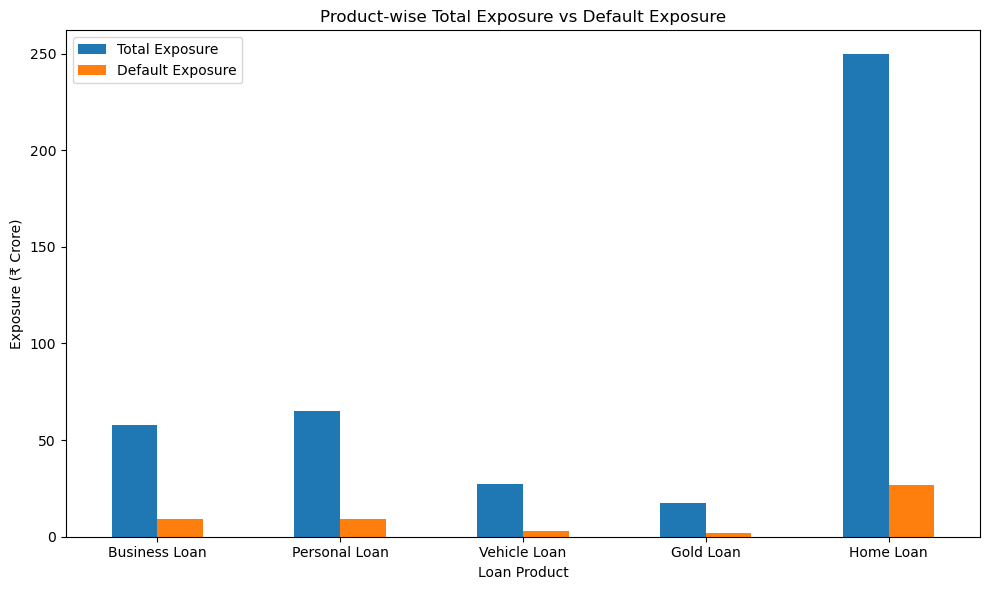

In [56]:
plot_data = product_analysis[
    ["total_exposure", "default_exposure"]
].copy() / 10_000_000

plot_data.plot(kind="bar", figsize=(10, 6))

plt.title("Product-wise Total Exposure vs Default Exposure")
plt.xlabel("Loan Product")
plt.ylabel("Exposure (₹ Crore)")
plt.xticks(rotation=0)
plt.legend(["Total Exposure", "Default Exposure"])
plt.tight_layout()
plt.show()


## 18. Product Default Rate Visualization

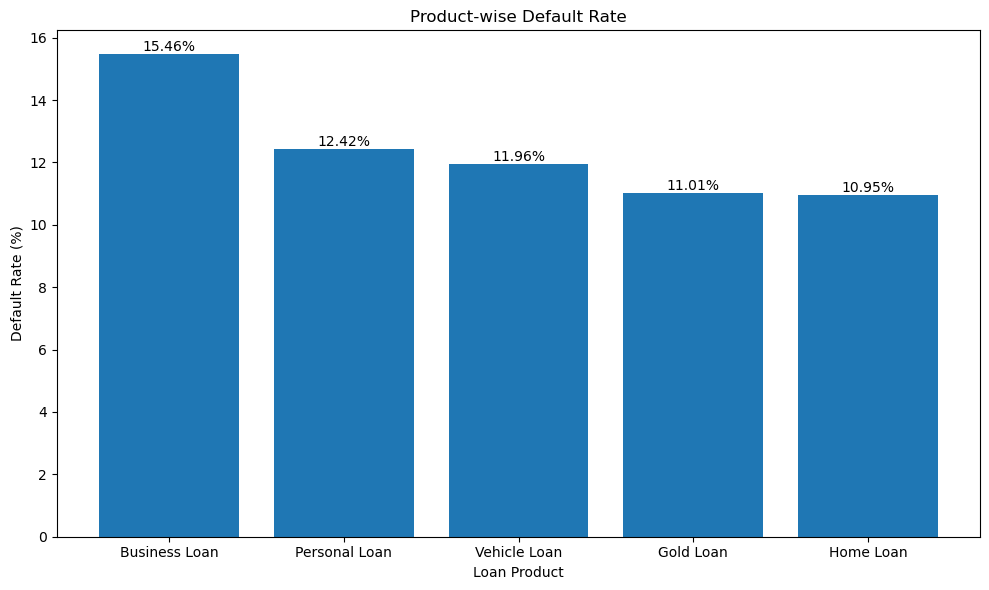

In [57]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    product_analysis.index,
    product_analysis["default_rate"]
)

plt.title("Product-wise Default Rate")
plt.xlabel("Loan Product")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


## 19. Key Business Insights

The final analysis supports the following observations:

1. The portfolio contains **8,000 customers** with approximately **₹417.04 Cr** of total loan exposure.
2. The overall default rate is approximately **12.47%**, with **998 default customers**.
3. **Business Loans** have the highest product-level default rate at approximately **15.46%**.
4. **Home Loans** account for the largest share of portfolio exposure, approximately **59.84%**, creating significant concentration exposure.
5. **Poor credit-risk customers** have the highest default rate among credit bands at approximately **18.83%**.
6. **Very High EMI burden** has the highest default rate among EMI segments at approximately **21.39%**.
7. The **High Risk** customer segment has approximately **605 customers**, **₹84.09 Cr exposure**, and a **16.36% default rate**.
8. **Medium Risk** customers carry the largest exposure share, so absolute exposure should be considered alongside default rate.
9. 90+ DPD exposure is approximately **₹50.03 Cr**, matching the default exposure because the synthetic dataset maps defaults to 90+ DPD.
10. The dataset is synthetic, so these relationships should be treated as analytical demonstrations rather than real-world causal findings.


## 20. Final Conclusion

This analysis demonstrates an end-to-end NBFC portfolio risk workflow:

**Data Quality → Feature Engineering → Risk Segmentation → Portfolio Analysis → Default/DPD Analysis → Business Insights**

The resulting analytical dataset and risk measures were also used to build the Power BI dashboard and SQL risk analysis.

### Final Portfolio Snapshot

- Customers: **8,000**
- Exposure: **₹417.04 Cr**
- Default Rate: **12.47%**
- Default Customers: **998**
- 90+ DPD Exposure: **₹50.03 Cr**
- High Risk Customers: **605**
- High Risk Exposure: **₹84.09 Cr**
- High Risk Default Rate: **16.36%**

**Project status: Python analysis complete.**
